Step 1: Data Ingestion and Noise Reduction;
Loading the raw ServiceNow export and immediately dropping administrative text columns (like work notes and assigned engineer) to reduce memory usage and eliminate noise from the dataset.

In [ ]:
import pandas as pd

# 1. Load your dataset
df = pd.read_csv('/task.csv', encoding='latin1')

# 2. Create a list of the exact column names you want to remove
# Updated column names based on the user's provided list
columns_to_drop = [
    'opened_by',
    'state',
    'assigned_to',
    'short_description',
    'assignment_group',
    'parent',
    'due_date',
    'approval',
    'comments_and_work_notes'
]

# 3. Drop the columns (axis=1 means drop columns, not rows)
df = df.drop(columns=columns_to_drop)

# Verify it worked by looking at the first 5 rows
print(df.head())

               number    priority  sys_class_name            opened_at  \
0    RITM000003137720         NaN  Requested Item  2025-09-01 05:02:32   
1  SCTASK000004257417         NaN    Catalog Task  2025-09-01 05:02:34   
2     INC000008536581  3 - Medium        Incident  2025-09-01 06:34:33   
3  SCTASK000004257463         NaN    Catalog Task  2025-09-01 07:16:04   
4  SCTASK000004257707  3 - Medium    Catalog Task  2025-09-01 08:40:13   

             closed_at  ref_rm_story.sprint ref_incident.incident_state  \
0  2025-09-03 05:05:21                  NaN                         NaN   
1  2025-09-03 05:05:14                  NaN                         NaN   
2  2025-09-12 16:01:51                  NaN                      Closed   
3  2025-09-01 12:02:54                  NaN                         NaN   
4  2025-09-02 10:07:52                  NaN                         NaN   

  ref_incident_task.incident.state  
0                              NaN  
1                             

Step 2: Isolating Relevant Workflows and Extracting Time Features;
Filtering the dataset strictly to 'Incident' records to ensure the model learns reactive break-fix patterns, rather than planned administrative tasks (RITMs). Converting raw text timestamps into datetime objects to extract actionable features like the hour and day of the week.

In [ ]:
# 1. Drop the extra backend reference columns ServiceNow snuck in
extra_noise = [
    'ref_rm_story.sprint',
    'ref_incident.incident_state',
    'ref_incident_task.incident.state'
]
df = df.drop(columns=extra_noise)

# 2. Filter the dataset to ONLY include Incidents (drops RITMs and SCTASKs)
df = df[df['sys_class_name'] == 'Incident'].copy()

# 3. Convert the exact timestamp columns to Pandas datetime objects
df['opened_at'] = pd.to_datetime(df['opened_at'], errors='coerce')
df['closed_at'] = pd.to_datetime(df['closed_at'], errors='coerce')

# 4. Drop any rows where the 'opened_at' date is corrupted or missing
df = df.dropna(subset=['opened_at'])

# 5. Feature Engineering: Extracting the time patterns
df['opened_hour'] = df['opened_at'].dt.hour
df['opened_day_of_week'] = df['opened_at'].dt.dayofweek  # Monday = 0, Sunday = 6
df['opened_date'] = df['opened_at'].dt.date

# Print the cleaned results to verify!
print(df[['number', 'priority', 'opened_at', 'opened_hour', 'opened_day_of_week']].head())

             number    priority           opened_at  opened_hour  \
2   INC000008536581  3 - Medium 2025-09-01 06:34:33            6   
28  INC000008537301     4 - Low 2025-09-01 14:12:28           14   
32  INC000008537578     4 - Low 2025-09-01 18:32:48           18   
37  INC000008539073     4 - Low 2025-09-02 00:39:03            0   
67  INC000008541479     4 - Low 2025-09-02 08:09:51            8   

    opened_day_of_week  
2                    0  
28                   0  
32                   0  
37                   1  
67                   1  


Step 3: Hourly Time-Series Aggregation & Feature Engineering;
Active Directory support operates in a 24/7 environment. Therefore, a daily aggregate is insufficient for practical shift optimization. The transactional dataset was resampled into a continuous 1-hour frequency. Missing hours (periods with zero tickets) were automatically filled to maintain chronological integrity. Temporal features (hour of the day, day of the week, and weekend flags) were extracted to capture intra-day operational spikes. The data was then split chronologically (80% training, 20% testing) to prevent data leakage.

In [ ]:
# Assuming 'df' is your cleaned dataframe of Incidents from Step 2

# 1. Create a continuous 24/7 hourly timeline
df_time = df.set_index('opened_at')
hourly_volume = df_time.resample('1H').size().reset_index(name='ticket_count')
hourly_volume.rename(columns={'opened_at': 'datetime'}, inplace=True)

# 2. Extract Shift-Specific Features
hourly_volume['hour_of_day'] = hourly_volume['datetime'].dt.hour
hourly_volume['day_of_week'] = hourly_volume['datetime'].dt.dayofweek
hourly_volume['is_weekend'] = hourly_volume['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# 3. Prepare for Machine Learning
hourly_volume.set_index('datetime', inplace=True)
X = hourly_volume[['hour_of_day', 'day_of_week', 'is_weekend']]
y = hourly_volume['ticket_count']

# 4. Chronological Train/Test Split (80/20)
split_index = int(len(hourly_volume) * 0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Professional 24/7 Timeline Established.")
print(f"Training Data: {len(X_train)} hours.")
print(f"Testing Data: {len(X_test)} hours.\n")

Professional 24/7 Timeline Established.
Training Data: 7071 hours.
Testing Data: 1768 hours.



/tmp/ipykernel_21190/194721920.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_volume = df_time.resample('1H').size().reset_index(name='ticket_count')


Step 4: Model Initialization, Hyperparameter Tuning, and Evaluation;
A Random Forest Regressor was implemented to forecast hourly incident volumes. To improve the model's sensitivity to sudden operational spikes (e.g., unexpected outages), hyperparameter tuning was applied. The bootstrap parameter was disabled and min_samples_leaf was minimized, allowing the decision trees to grow deep and capture rare, extreme anomalies rather than smoothing them into an average baseline. The tuned model was trained on the 80% chronological split, and performance was quantified using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) against the 20% testing holdout.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Initialize the Aggressive Random Forest Model
# - bootstrap=False: Stops the model from averaging out the extreme spikes.
# - min_samples_leaf=1: Allows the model to memorize rare, extreme events.
# - max_depth=None: Lets the decision trees grow deep enough to find complex spike patterns.
rf_model_tuned = RandomForestRegressor(
    n_estimators=100,
    bootstrap=False,
    min_samples_leaf=1,
    max_depth=None,
    random_state=42
)

# 2. Train the Tuned Model
rf_model_tuned.fit(X_train, y_train)

# 3. Generate New Predictions
predictions_tuned = rf_model_tuned.predict(X_test)

# 4. Evaluate the Tuned Model
mae_tuned = mean_absolute_error(y_test, predictions_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, predictions_tuned))

print("Tuned Model Training Complete!")
print(f"New Mean Absolute Error (MAE): {mae_tuned:.2f} tickets per hour")
print(f"New Root Mean Squared Error (RMSE): {rmse_tuned:.2f} tickets per hour")

Tuned Model Training Complete!
New Mean Absolute Error (MAE): 0.64 tickets per hour
New Root Mean Squared Error (RMSE): 0.88 tickets per hour


Step 5: Visualizing Model Predictions vs. Actual Volumes;
To validate the model's performance visually, the forecasted ticket volumes were plotted against the actual historical volumes. For visual clarity, the plot zooms in on a 72-hour operational window from the testing holdout. This visualization demonstrates the model's ability to track intra-day operational spikes and provides a clear, intuitive look at expected queue behavior for capacity planning.

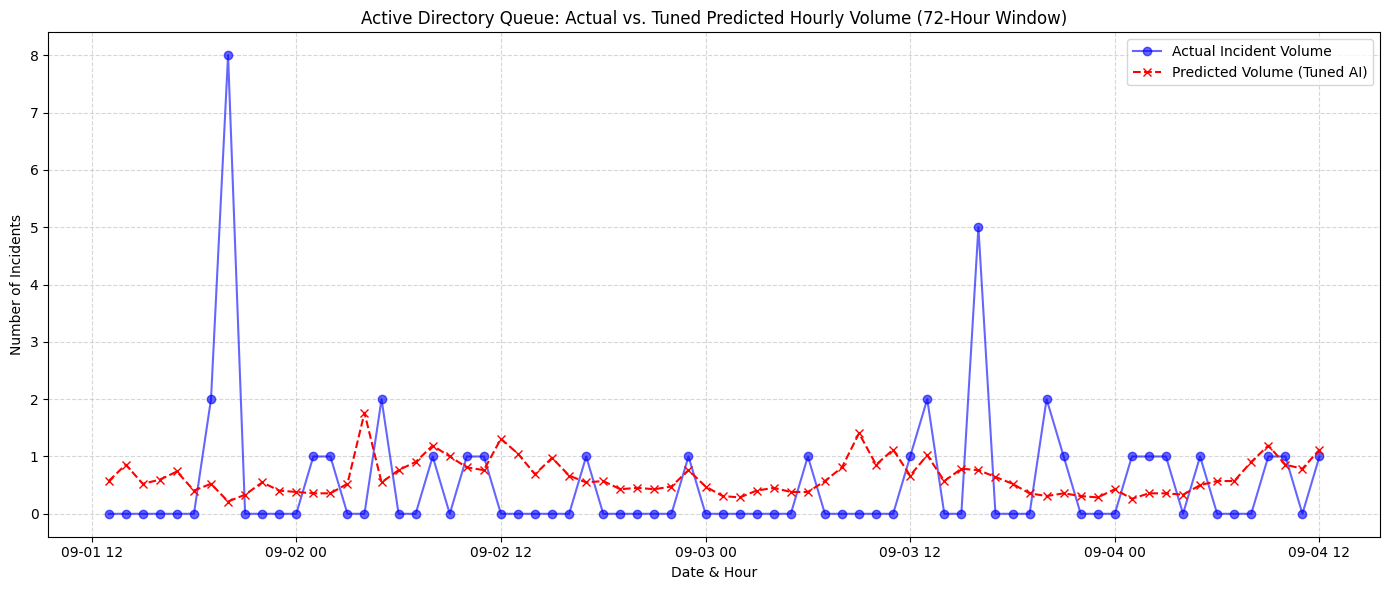

In [ ]:
import matplotlib.pyplot as plt

# 1. Zoom in on the final 72 hours (3 days) of the test set
plot_actuals = y_test.iloc[-72:]
# FIX: Use the new 'predictions_tuned' variable!
plot_predictions = predictions_tuned[-72:]

# 2. Build the visual comparison
plt.figure(figsize=(14, 6))

# Plot the real ticket counts in solid blue
plt.plot(plot_actuals.index, plot_actuals.values, label='Actual Incident Volume', marker='o', color='blue', alpha=0.6)

# Plot the AI's tuned predictions in dashed red
plt.plot(plot_actuals.index, plot_predictions, label='Predicted Volume (Tuned AI)', marker='x', color='red', linestyle='--')

# 3. Format the chart for the final report
plt.title('Active Directory Queue: Actual vs. Tuned Predicted Hourly Volume (72-Hour Window)')
plt.xlabel('Date & Hour')
plt.ylabel('Number of Incidents')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Display the chart right in your mobile browser!
plt.show()